Shape: (1323648,)
Sampling rate: 22050


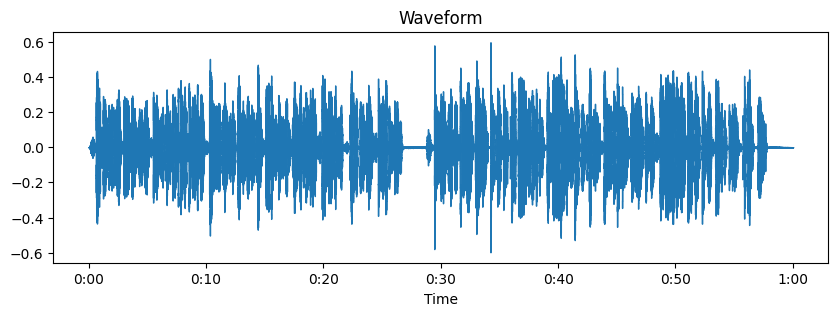

MFCC shape: (13, 2586)
Final feature shape: (13,)


In [ ]:
# Audio Classification Pipeline

# feature extraction pipeline for one audio file, to extract mfcc features and prepare for model input

import librosa
import os

# pick one file manually
file_path = "data/speech/speech1.wav"

y, sr = librosa.load(file_path, sr=22050)

print("Shape:", y.shape)
print("Sampling rate:", sr)

import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print("MFCC shape:", mfcc.shape)

import numpy as np

mfcc_mean = np.mean(mfcc, axis=1)

print("Final feature shape:", mfcc_mean.shape)


In [10]:
import os
import numpy as np
import librosa

data_path = "data"

features = []
labels = []

classes = ["speech", "music", "noise"]

# loop through each class folder and extract features
for label in classes:
    folder = os.path.join(data_path, label)
    
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        
        y, sr = librosa.load(file_path, sr=22050)
        
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

        zcr = np.mean(librosa.feature.zero_crossing_rate(y))

        feature_vector = np.concatenate([
            mfcc_mean,
            mfcc_std,
            [centroid],
            [zcr]
        ])
        features.append(feature_vector)
        labels.append(label)

# convert to numpy arrays
X = np.array(features)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

# encode labels to integers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(y[:5])
print(y_encoded[:5])

print(le.classes_)

# split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# train random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y_encoded, cv=5)

print("CV scores:", scores)
print("Mean:", scores.mean())

X shape: (33, 28)
y shape: (33,)
['speech' 'speech' 'speech' 'speech' 'speech']
[2 2 2 2 2]
['music' 'noise' 'speech']
Accuracy: 0.5714285714285714
Confusion Matrix:
 [[2 0 1]
 [1 1 0]
 [1 0 1]]
CV scores: [0.71428571 1.         0.85714286 0.66666667 0.66666667]
Mean: 0.780952380952381
